In [34]:
import numpy as np
import tqdm
import matplotlib.pyplot as plt


def total_least_squares(X, Y):
    """
    Solves for K and B in Y = KX + B using TLS via SVD.
    X: input data (n_samples, n_features)
    Y: output data (n_samples, n_targets)
    """
    n_samples = X.shape[0]
    
    # 1. Handle the intercept (b) by centering the data
    X_mu = np.mean(X, axis=0)
    Y_mu = np.mean(Y, axis=0)
    
    X_centered = X - X_mu
    Y_centered = Y - Y_mu
    
    # 2. Augment the matrices [X | Y]
    Z = np.hstack((X_centered, Y_centered))
    
    # 3. Perform Singular Value Decomposition
    # Z = U @ S @ V_transpose
    _, _, Vt = np.linalg.svd(Z)
    V = Vt.T
    
    # 4. Partition V to extract the solution
    # For Y = XK, the solution is derived from the last columns of V
    n_features = X.shape[1]
    
    V12 = V[:n_features, n_features:]
    V22 = V[n_features:, n_features:]
    
    # K = -V12 @ inv(V22)
    K = -V12 @ np.linalg.inv(V22)
    
    # 5. Recover the intercept B: B = Y_mu - X_mu @ K
    B = Y_mu - X_mu @ K
    
    return K, B


def TLS_null(X, Y):
    """
    Solves for K and B in Y = KX + B using TLS via SVD.
    X: input data (n_samples, n_features)
    Y: output data (n_samples, n_targets)
    """
    
    # 1. Handle the intercept (b) by centering the data
    X_mu = np.mean(X, axis=0)
    Y_mu = np.mean(Y, axis=0)
    
    X_centered = X - X_mu*0
    Y_centered = Y - Y_mu*0
    
    # 2. Augment the matrices [X | Y]
    Z = np.hstack((X_centered, Y_centered))
    
    # 3. Perform Singular Value Decomposition
    # Z = U @ S @ V_transpose
    _, S, Vt = np.linalg.svd(Z)
    # print(S)
    V = Vt.T
    
    # 4. Partition V to extract the solution
    # For Y = XK, the solution is derived from the last columns of V
    n_features = X.shape[1]
    return V[:, n_features:]

# --- Test Case ---
np.random.seed(42)
T = 100
n= 10
true_k = np.random.randn(n, 1) # Vector k
true_b = np.random.randn(1)           # Scalar b (offset)

# Generate X data
X_true = np.random.randn(T, n)
# Generate Y = Xk + b
Y_true = X_true @ true_k + true_b
# Add noise to BOTH X and Y (The TLS condition)
X_noisy = X_true + np.random.normal(0, 1e-3, X_true.shape)
Y_noisy = Y_true + np.random.normal(0, 1e-3, Y_true.shape)

# Estimate
nullEst= TLS_null(X_noisy, Y_noisy)
print(nullEst.shape)
dirMat= np.random.randn(1, n)

(11, 1)


In [47]:
rankH= n
numPop= 1e3
loops= 10

expEmp= []
expGen= []
expEmpStd= []
expGenStd= []
expEmpCal= []
expGenCal= []
numSpales= []
tmpWants = []
tmpWants2 = []
tmpWantsCal= []
for j in tqdm.tqdm(range(loops)):
    stdOfNoise= 1e-1*10**(-4+j/loops*4)
    empList= []
    genList= []
    HXMean= 0
    numTrain= n+5
    numSpales.append(stdOfNoise)
    tmpWanted= []
    tmpWanted2= []
    for i in range(5000):
        # Generate X data
        X_true = np.random.randn(numTrain, n)*dirMat
        # Generate Y = Xk + b
        Y_true = X_true @ true_k
        # Add noise to BOTH X and Y (The TLS condition)
        X_noisy = X_true + np.random.normal(0, stdOfNoise, X_true.shape)
        Y_noisy = Y_true + np.random.normal(0, stdOfNoise, Y_true.shape)
        Z_noise = np.hstack((X_noisy-np.mean(X_noisy, axis=0)*0, Y_noisy-np.mean(Y_noisy, axis=0)*0))
        
        # Generate X data
        X_pop = np.random.randn(int(numPop), n)*dirMat
        # Generate Y = Xk + b
        Y_pop = X_pop @ true_k 
        # Add noise to BOTH X and Y (The TLS condition)
        X_pop_noise = X_pop + np.random.normal(0, stdOfNoise, X_pop.shape)
        Y_pop_noise = Y_pop + np.random.normal(0, stdOfNoise, Y_pop.shape)
        Z_pop_noise = np.hstack((X_pop_noise-np.mean(X_pop_noise, axis=0)*0, Y_pop_noise-np.mean(Y_pop_noise, axis=0)*0))
        NiE= TLS_null(X_noisy, Y_noisy)

        empList.append(np.mean(np.square(Z_noise@NiE)))
        genList.append(np.mean(np.square(Z_pop_noise@NiE)))

    expEmp.append(np.mean(empList))
    expGen.append(np.mean(genList))
    expEmpStd.append(np.std(empList))
    expGenStd.append(np.std(genList))
    expEmpCal.append(stdOfNoise**2-rankH/numTrain*stdOfNoise**2)
    expGenCal.append(stdOfNoise**2+rankH/(numTrain-rankH-1)*stdOfNoise**2)


100%|██████████| 10/10 [00:23<00:00,  2.36s/it]


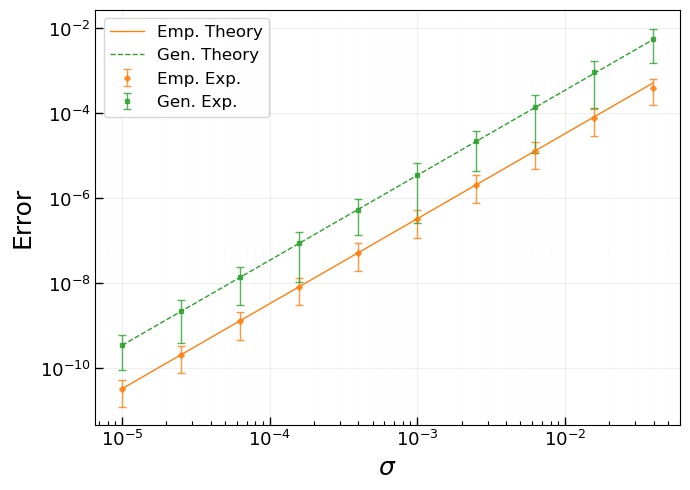

In [48]:
# Convert lists to numpy arrays for easy math operations (like jittering)
numSpales_arr = np.array(numSpales)
jitter = 0  # Adjust this value based on your X-axis scale
plt.figure(figsize=(7, 5))
# 1. Empirical Data: Jittered slightly to the left
plt.errorbar(numSpales_arr - jitter, expEmp, yerr=expEmpStd, 
             fmt='D', markersize=3, capsize=3, elinewidth=1,
             color='C1', label='Emp. Exp.', alpha=0.8)
# 2. Empirical Theory: Solid line
plt.plot(numSpales_arr - jitter, expEmpCal, linewidth=1, 
         label="Emp. Theory", color='C1', linestyle='-')
# 3. General Data: Jittered slightly to the right
plt.errorbar(numSpales_arr + jitter, expGen, yerr=expGenStd, 
             fmt='s', markersize=3, capsize=3, elinewidth=1,
             color='C2', label='Gen. Exp.', alpha=0.8)
# 4. General Theory: Dashed line for visual distinction (Colorblind friendly)
plt.plot(numSpales_arr + jitter, expGenCal, linewidth=1, 
         label="Gen. Theory", color='C2', linestyle='--')
# Aesthetics
plt.xlabel(r'$\sigma$', fontsize=18)
plt.ylabel(r'Error', fontsize=18)
plt.yscale("log")
plt.xscale("log")
# Improved Grid: Distinct major and minor lines
plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.3)
plt.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.2)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tick_params(axis='both', which='major', direction='in', length=6, width=1)
plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
# Legend: Organized into two columns to save vertical space if needed
plt.legend(fontsize=12, loc='upper left', frameon=True, ncol=1)
plt.tight_layout()
plt.show()

In [45]:
rankH= n
T = 2*n
numPop= 1e3
loops= 30

expEmp= []
expGen= []
expEmpStd= []
expGenStd= []
expEmpCal= []
expGenCal= []
numSpales= []
tmpWants = []
tmpWants2 = []
tmpWantsCal= []
for j in tqdm.tqdm(range(loops)):
    stdOfNoise= 1e-2
    empList= []
    genList= []
    HXMean= 0
    numTrain= n+2+int(j*100/loops)
    numSpales.append(numTrain)
    tmpWanted= []
    tmpWanted2= []
    for i in range(1000):
        # Generate X data
        X_true = np.random.randn(numTrain, n)*dirMat
        # Generate Y = Xk + b
        Y_true = X_true @ true_k 
        # Add noise to BOTH X and Y (The TLS condition)
        X_noisy = X_true + np.random.normal(0, stdOfNoise, X_true.shape)
        Y_noisy = Y_true + np.random.normal(0, stdOfNoise, Y_true.shape)
        Z_noise = np.hstack((X_noisy-np.mean(X_noisy, axis=0)*0, Y_noisy-np.mean(Y_noisy, axis=0)*0))
        
        # Generate X data
        X_pop = np.random.randn(int(numPop), n)*dirMat
        # Generate Y = Xk + b
        Y_pop = X_pop @ true_k 
        # Add noise to BOTH X and Y (The TLS condition)
        X_pop_noise = X_pop + np.random.normal(0, stdOfNoise, X_pop.shape)
        Y_pop_noise = Y_pop + np.random.normal(0, stdOfNoise, Y_pop.shape)
        Z_pop_noise = np.hstack((X_pop_noise-np.mean(X_pop_noise, axis=0)*0, Y_pop_noise-np.mean(Y_pop_noise, axis=0)*0))
        NiE= TLS_null(X_noisy, Y_noisy)

        empList.append(np.mean(np.square(Z_noise@NiE)))
        genList.append(np.mean(np.square(Z_pop_noise@NiE)))

    expEmp.append(np.mean(empList))
    expGen.append(np.mean(genList))
    expEmpStd.append(np.std(empList))
    expGenStd.append(np.std(genList))
    expEmpCal.append(stdOfNoise**2-rankH/(numTrain)*stdOfNoise**2)
    expGenCal.append(stdOfNoise**2+rankH/(numTrain-rankH-1)*stdOfNoise**2)


100%|██████████| 30/30 [00:16<00:00,  1.86it/s]


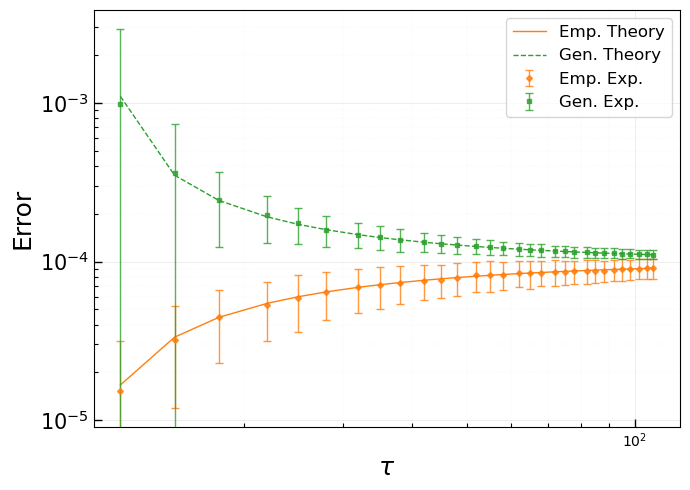

In [46]:
# Convert lists to numpy arrays for easy math operations (like jittering)
numSpales_arr = np.array(numSpales)
jitter = 0  # Adjust this value based on your X-axis scale
plt.figure(figsize=(7, 5))
# 1. Empirical Data: Jittered slightly to the left
plt.errorbar(numSpales_arr - jitter, expEmp, yerr=expEmpStd, 
             fmt='D', markersize=3, capsize=3, elinewidth=1,
             color='C1', label='Emp. Exp.', alpha=0.8)
# 2. Empirical Theory: Solid line
plt.plot(numSpales_arr - jitter, expEmpCal, linewidth=1, 
         label="Emp. Theory", color='C1', linestyle='-')
# 3. General Data: Jittered slightly to the right
plt.errorbar(numSpales_arr + jitter, expGen, yerr=expGenStd, 
             fmt='s', markersize=3, capsize=3, elinewidth=1,
             color='C2', label='Gen. Exp.', alpha=0.8)
# 4. General Theory: Dashed line for visual distinction (Colorblind friendly)
plt.plot(numSpales_arr + jitter, expGenCal, linewidth=1, 
         label="Gen. Theory", color='C2', linestyle='--')
# Aesthetics
plt.xlabel(r'$\tau$', fontsize=18)
plt.ylabel(r'Error', fontsize=18)
plt.yscale("log")
plt.xscale("log")
# Improved Grid: Distinct major and minor lines
plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.3)
plt.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.2)
# plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tick_params(axis='both', which='major', direction='in', length=6, width=1)
plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
# Legend: Organized into two columns to save vertical space if needed
plt.legend(fontsize=12, loc='upper right', frameon=True, ncol=1)
plt.tight_layout()
plt.show()